# 📊 Exploratory Data Analysis (EDA)
### Role 2 — Data Analyst: Exploration & Insights

This notebook explores the processed sales data to understand distributions, seasonality, store/item trends, and validate preprocessing decisions before modeling.

**Data Sources:**
- `data/processed/daily_sales.csv` — Silver/daily (913k rows)
- `data/processed/weekly_sales.csv` — Silver/weekly (131k rows)
- `data/processed/weekly_sales_engineered.csv` — Gold/features (105k rows)

In [126]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings, os

warnings.filterwarnings('ignore')

# ── Style ────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0e1117',
    'axes.facecolor':   '#0e1117',
    'axes.edgecolor':   '#30363d',
    'axes.labelcolor':  '#c9d1d9',
    'text.color':       '#c9d1d9',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'grid.color':       '#21262d',
    'grid.alpha':       0.6,
    'font.family':      'sans-serif',
    'font.size':        11,
    'axes.titlesize':   14,
    'axes.titleweight': 'bold',
    'figure.dpi':       120,
})

PALETTE = ['#58a6ff', '#f0883e', '#3fb950', '#bc8cff', '#f778ba',
           '#79c0ff', '#d29922', '#56d4dd', '#ff7b72', '#7ee787']

PLOTS_DIR = os.path.join('..', 'results', 'plots')
os.makedirs(PLOTS_DIR, exist_ok=True)

def save(fig, name):
    fig.savefig(os.path.join(PLOTS_DIR, name), bbox_inches='tight', dpi=150, facecolor=fig.get_facecolor())

print('✅ Styling loaded')

✅ Styling loaded


In [127]:
# ── Load all three layers ────────────────────────────────────────
df_daily  = pd.read_csv('../data/processed/daily_sales.csv', parse_dates=['date'])
df_weekly = pd.read_csv('../data/processed/weekly_sales.csv')
df_gold   = pd.read_csv('../data/processed/weekly_sales_engineered.csv')

print(f'Daily  : {df_daily.shape[0]:>10,} rows  ×  {df_daily.shape[1]} cols')
print(f'Weekly : {df_weekly.shape[0]:>10,} rows  ×  {df_weekly.shape[1]} cols')
print(f'Gold   : {df_gold.shape[0]:>10,} rows  ×  {df_gold.shape[1]} cols')

Daily  :    913,000 rows  ×  5 cols
Weekly :    131,000 rows  ×  6 cols
Gold   :    105,000 rows  ×  17 cols


---
## Section 1 — Basic Statistics

In [128]:
# Schema and dtypes
print('═' * 50)
print('  Weekly Sales Schema')
print('═' * 50)
print(df_weekly.dtypes.to_string())
print(f'\nRow count : {len(df_weekly):,}')
print(f'Null count: {df_weekly.isnull().sum().sum()}')
print()
df_weekly['weekly_sales'].describe().round(2)

══════════════════════════════════════════════════
  Weekly Sales Schema
══════════════════════════════════════════════════
item                int64
year                int64
week_of_year        int64
weekly_sales        int64
week_has_holiday    int64
store               int64

Row count : 131,000
Null count: 0



count    131000.00
mean        364.16
std         189.73
min          23.00
25%         211.00
50%         332.00
75%         485.00
max        1210.00
Name: weekly_sales, dtype: float64

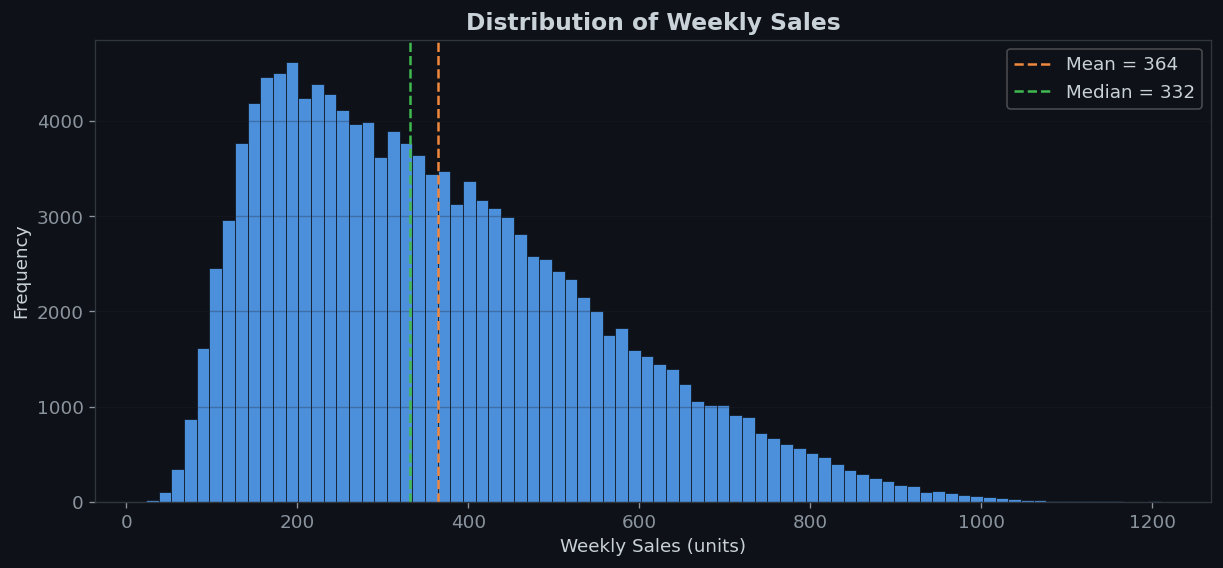

In [129]:
# Distribution of weekly sales (histogram)
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(df_weekly['weekly_sales'], bins=80, color=PALETTE[0], alpha=0.85, edgecolor='#0e1117', linewidth=0.5)

mean_val = df_weekly['weekly_sales'].mean()
median_val = df_weekly['weekly_sales'].median()
ax.axvline(mean_val, color=PALETTE[1], ls='--', lw=1.5, label=f'Mean = {mean_val:.0f}')
ax.axvline(median_val, color=PALETTE[2], ls='--', lw=1.5, label=f'Median = {median_val:.0f}')

ax.set(title='Distribution of Weekly Sales', xlabel='Weekly Sales (units)', ylabel='Frequency')
ax.legend(framealpha=0.3)
ax.grid(axis='y', alpha=0.3)
save(fig, '1_weekly_sales_distribution.png')
plt.show()

---
## Section 2 — Temporal Trends

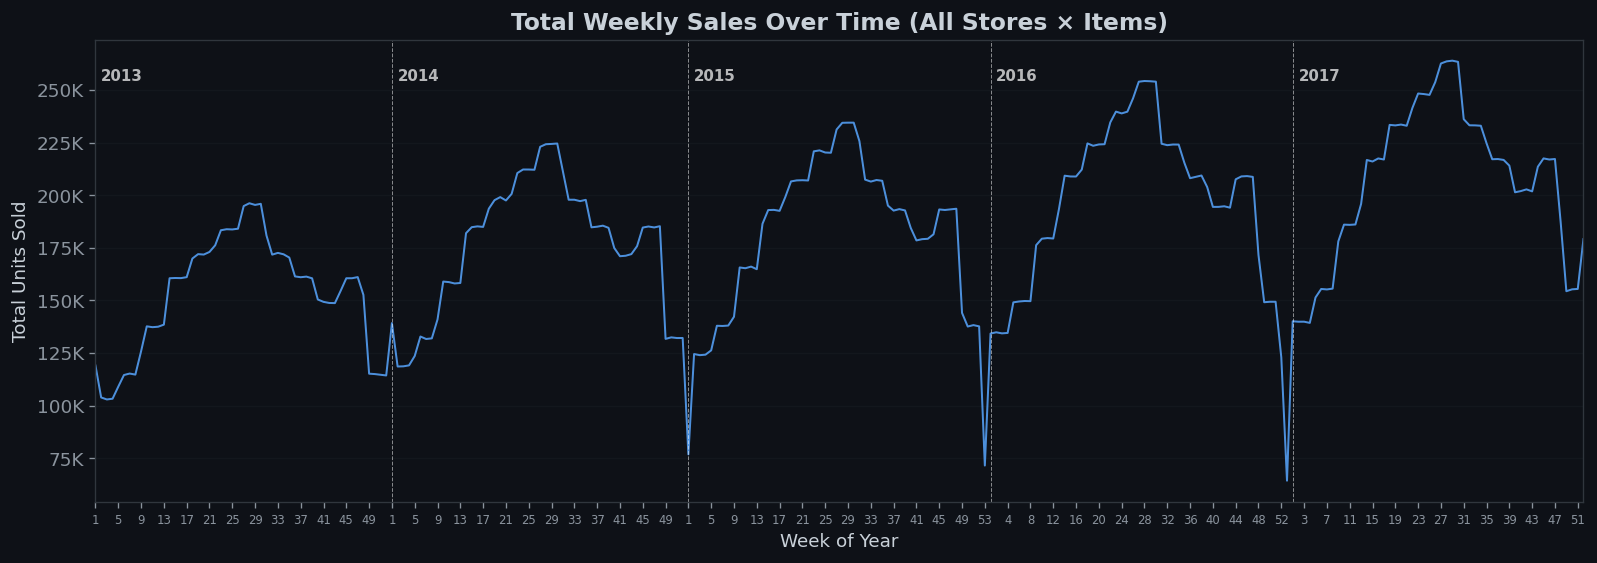

In [130]:
# 2a. Total weekly sales over time — single continuous trend
weekly_total = df_weekly.groupby(['year', 'week_of_year'])['weekly_sales'].sum().reset_index()
weekly_total = weekly_total.sort_values(['year', 'week_of_year']).reset_index(drop=True)
years = sorted(weekly_total['year'].unique())

# Build a sequential x-position (0, 1, 2, …) so the line is continuous
weekly_total['seq'] = range(len(weekly_total))

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(weekly_total['seq'], weekly_total['weekly_sales'],
        color=PALETTE[0], lw=1.2, alpha=0.85)

# --- x-axis: repeating week-of-year labels per year ---
tick_positions = weekly_total['seq'].tolist()
tick_labels    = [str(w) for w in weekly_total['week_of_year']]
# Show a label every 4 weeks to avoid clutter
sparse_pos    = [p for i, p in enumerate(tick_positions) if i % 4 == 0]
sparse_labels = [l for i, l in enumerate(tick_labels)    if i % 4 == 0]
ax.set_xticks(sparse_pos)
ax.set_xticklabels(sparse_labels, fontsize=7)
ax.set_xlim(tick_positions[0], tick_positions[-1])

# --- vertical dividers + year annotations at year boundaries ---
for yr in years:
    first_idx = weekly_total.loc[weekly_total['year'] == yr, 'seq'].iloc[0]
    ax.axvline(first_idx, color='white', ls='--', lw=0.6, alpha=0.5)
    # place year label slightly right of the divider, near the top
    ax.text(first_idx + 1, ax.get_ylim()[1] * 0.95, str(yr),
            color='white', fontsize=9, fontweight='bold',
            va='top', ha='left', alpha=0.7)

ax.set(title='Total Weekly Sales Over Time (All Stores × Items)',
       xlabel='Week of Year', ylabel='Total Units Sold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax.grid(axis='y', alpha=0.3)
save(fig, '2a_total_weekly_sales_over_time.png')
plt.show()

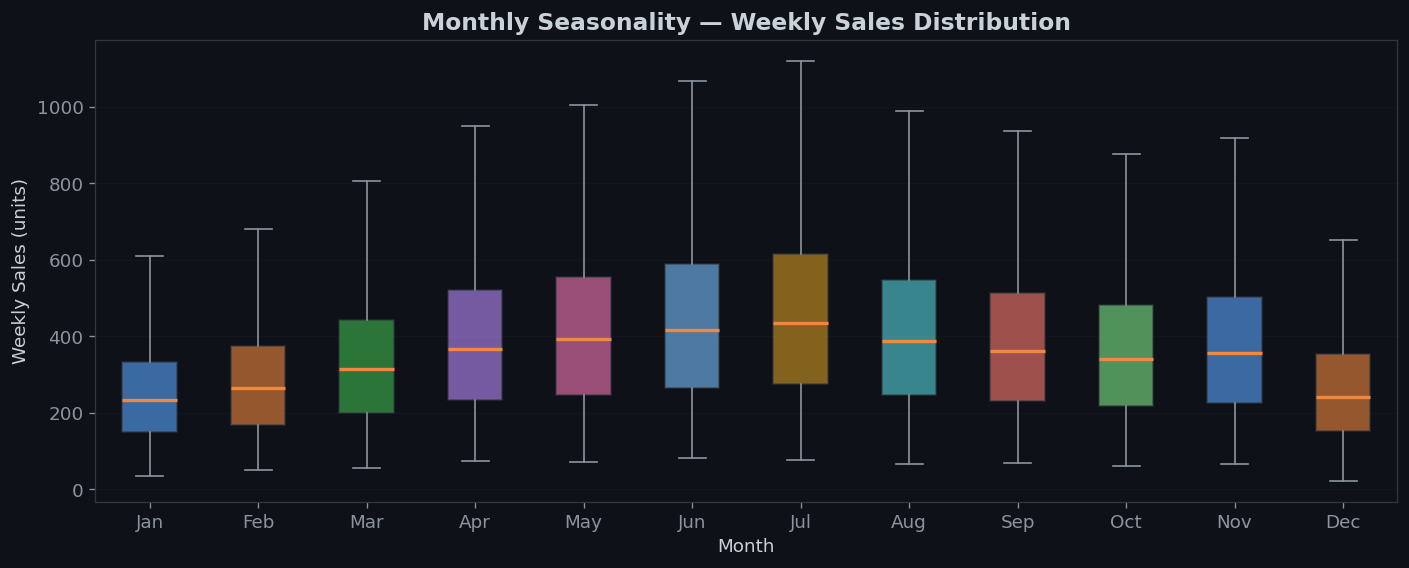

In [131]:
# 2b. Monthly seasonality box plot
df_weekly_m = df_weekly.copy()
# Approximate month from week_of_year
df_weekly_m['month'] = np.clip(((df_weekly_m['week_of_year'] - 1) * 12 // 52) + 1, 1, 12)
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(14, 5))
bp = ax.boxplot(
    [df_weekly_m[df_weekly_m['month'] == m]['weekly_sales'] for m in range(1, 13)],
    labels=month_names, patch_artist=True, showfliers=False,
    medianprops=dict(color='#f0883e', lw=2),
    whiskerprops=dict(color='#8b949e'), capprops=dict(color='#8b949e')
)
for patch, c in zip(bp['boxes'], PALETTE[:12] * 2):
    patch.set_facecolor(c)
    patch.set_alpha(0.6)
    patch.set_edgecolor('#30363d')

ax.set(title='Monthly Seasonality — Weekly Sales Distribution', xlabel='Month', ylabel='Weekly Sales (units)')
ax.grid(axis='y', alpha=0.3)
save(fig, '2b_monthly_seasonality_boxplot.png')
plt.show()

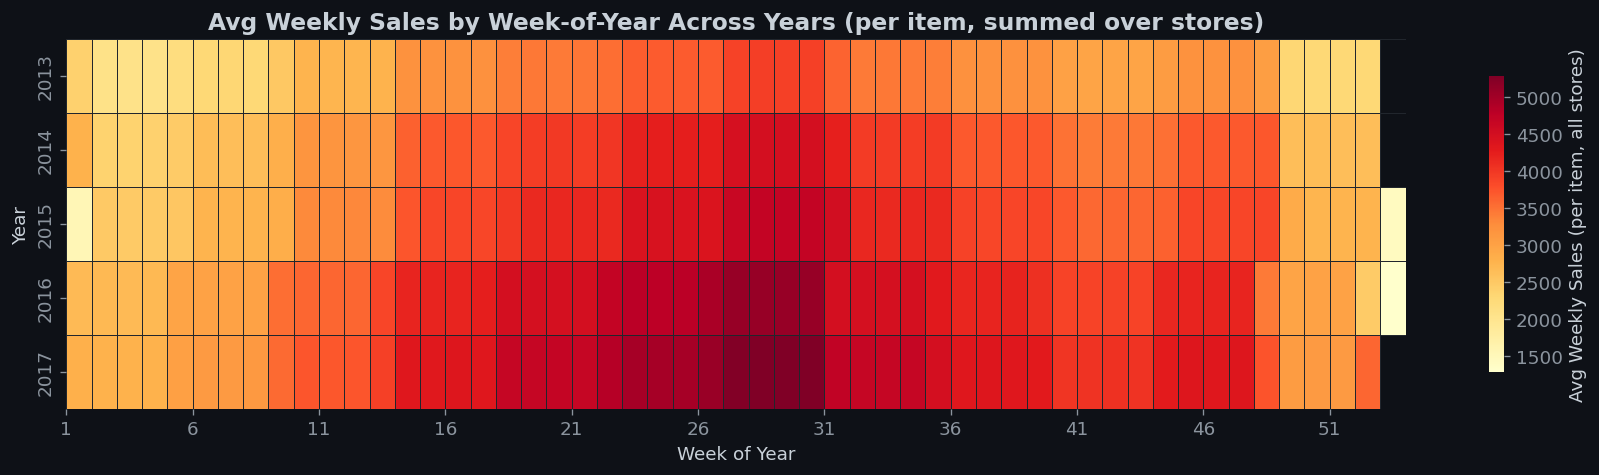

In [132]:
# 2c. Week-of-year heatmap — avg weekly sales (sum across stores per item, then avg across items)
# Step 1: sum across stores for each (item, year, week_of_year)
item_week_totals = df_weekly.groupby(['item', 'year', 'week_of_year'])['weekly_sales'].sum().reset_index()
# Step 2: average across items for each (year, week_of_year)
pivot = item_week_totals.groupby(['year', 'week_of_year'])['weekly_sales'].mean().reset_index()
pivot_table = pivot.pivot(index='year', columns='week_of_year', values='weekly_sales')

fig, ax = plt.subplots(figsize=(18, 4))
sns.heatmap(
    pivot_table, ax=ax, cmap='YlOrRd', linewidths=0.3, linecolor='#21262d',
    cbar_kws={'label': 'Avg Weekly Sales (per item, all stores)', 'shrink': 0.8}
)
ax.set(title='Avg Weekly Sales by Week-of-Year Across Years (per item, summed over stores)',
       xlabel='Week of Year', ylabel='Year')
# Show every 5th week label
xticks = [i for i in range(0, pivot_table.shape[1], 5)]
ax.set_xticks(xticks)
ax.set_xticklabels([pivot_table.columns[i] for i in xticks], rotation=0)
save(fig, '2c_week_of_year_heatmap.png')
plt.show()

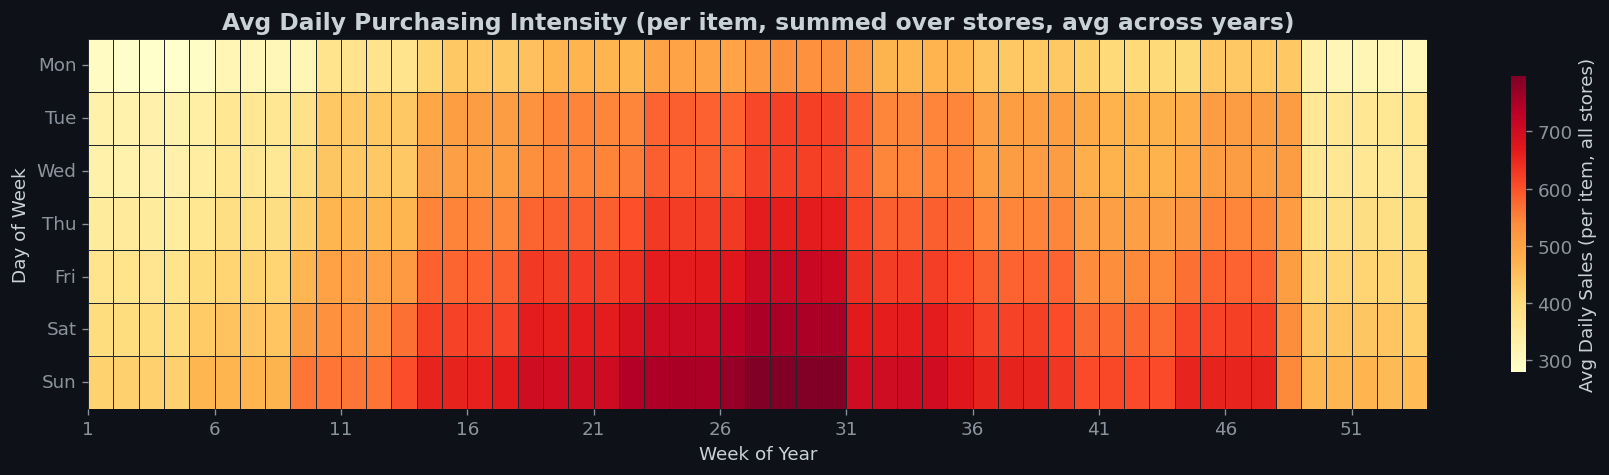

In [133]:
# 2d. Daily Purchasing Intensity Heatmap — avg across all years
# (sum across stores per item first, then average across items & years)
df_daily['day_of_week'] = df_daily['date'].dt.dayofweek
df_daily['week_iso']    = df_daily['date'].dt.isocalendar().week.astype(int)

# Step 1: sum across stores for each (item, date)
item_day_totals = df_daily.groupby(['item', 'date', 'day_of_week', 'week_iso'])['sales'].sum().reset_index()
# Step 2: average across items & years for each (day_of_week, week_iso)
heat_avg = item_day_totals.groupby(['day_of_week', 'week_iso'])['sales'].mean().reset_index()
pivot_heat = heat_avg.pivot_table(
    index='day_of_week', columns='week_iso', values='sales', aggfunc='mean'
)

fig, ax = plt.subplots(figsize=(18, 4))
sns.heatmap(
    pivot_heat, cmap='YlOrRd', ax=ax,
    linewidths=0.3, linecolor='#21262d',
    cbar_kws={'label': 'Avg Daily Sales (per item, all stores)', 'shrink': 0.8}
)
ax.set_yticks(np.arange(7) + 0.5)
ax.set_yticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'],
                   rotation=0, color='#8b949e')
# Show every 5th week label
xticks = [i for i in range(0, pivot_heat.shape[1], 5)]
ax.set_xticks(xticks)
ax.set_xticklabels([pivot_heat.columns[i] for i in xticks], rotation=0)
ax.set(title='Avg Daily Purchasing Intensity (per item, summed over stores, avg across years)',
       xlabel='Week of Year', ylabel='Day of Week')
save(fig, '2d_daily_purchasing_heatmap.png')
plt.show()

---
## Section 3 — Store-Level Analysis

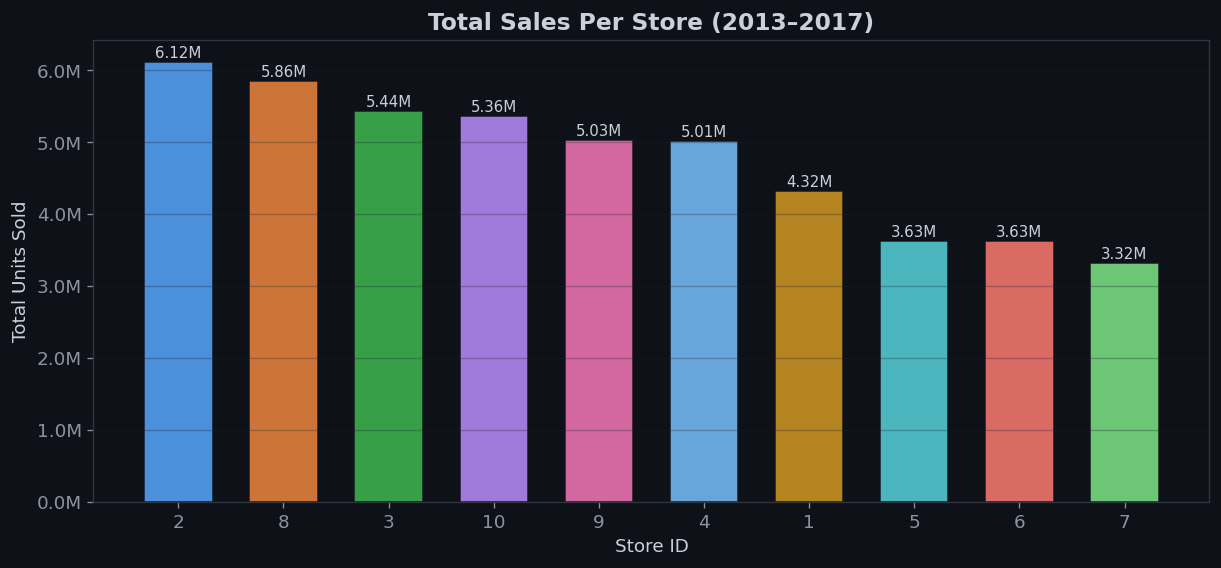

In [134]:
# 3a. Total sales per store (bar chart)
store_total = df_weekly.groupby('store')['weekly_sales'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(store_total.index.astype(str), store_total.values, color=PALETTE[:10], alpha=0.85, edgecolor='#0e1117', width=0.65)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + store_total.max()*0.01,
            f'{height/1e6:.2f}M', ha='center', fontsize=9, color='#c9d1d9')

ax.set(title='Total Sales Per Store (2013–2017)', xlabel='Store ID', ylabel='Total Units Sold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.grid(axis='y', alpha=0.3)
save(fig, '3a_total_sales_per_store.png')
plt.show()

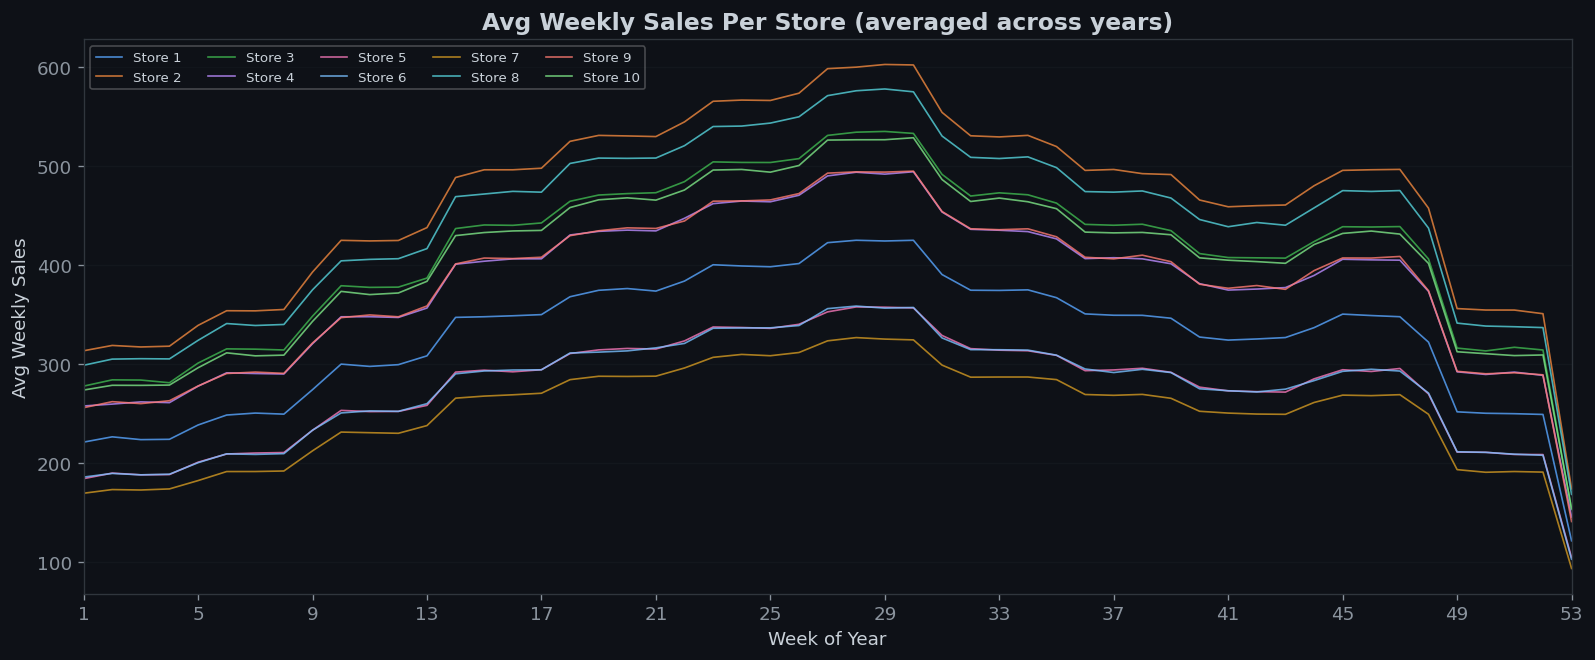

In [135]:
# 3b. Average weekly sales per store — by Week of Year
store_weekly = df_weekly.groupby(['store', 'year', 'week_of_year'])['weekly_sales'].mean().reset_index()
store_weekly = store_weekly.sort_values(['store', 'year', 'week_of_year'])
stores = sorted(df_weekly['store'].unique())
years  = sorted(df_weekly['year'].unique())

fig, ax = plt.subplots(figsize=(16, 6))
for i, store_id in enumerate(stores):
    # average across years for each week_of_year
    sub = store_weekly[store_weekly['store'] == store_id]
    avg = sub.groupby('week_of_year')['weekly_sales'].mean().reset_index()
    ax.plot(avg['week_of_year'], avg['weekly_sales'],
            label=f'Store {store_id}', color=PALETTE[i % len(PALETTE)], lw=1, alpha=0.8)

ax.set(title='Avg Weekly Sales Per Store (averaged across years)',
       xlabel='Week of Year', ylabel='Avg Weekly Sales')
ax.set_xticks(range(1, 54, 4))
ax.set_xlim(1, 53)
ax.legend(ncol=5, loc='upper left', framealpha=0.3, fontsize=8)
ax.grid(axis='y', alpha=0.3)
save(fig, '3b_avg_weekly_sales_per_store.png')
plt.show()

---
## Section 4 — Item-Level Analysis

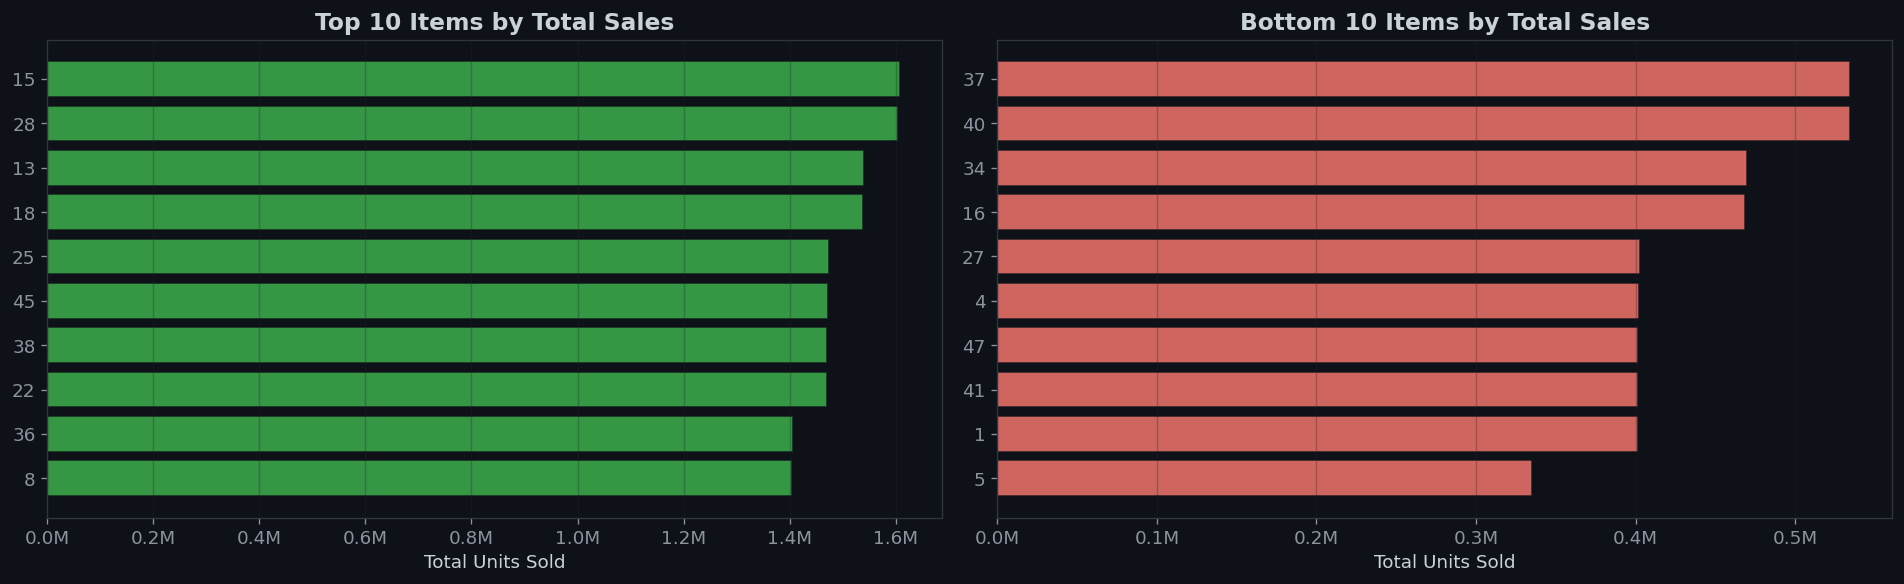

In [136]:
# 4a. Top 10 and Bottom 10 items by total sales
item_total = df_weekly.groupby('item')['weekly_sales'].sum().sort_values(ascending=False)
top10 = item_total.head(10)
bot10 = item_total.tail(10).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Top 10
axes[0].barh(top10.index.astype(str)[::-1], top10.values[::-1], color=PALETTE[2], alpha=0.8, edgecolor='#0e1117')
axes[0].set(title='Top 10 Items by Total Sales', xlabel='Total Units Sold')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# Bottom 10
axes[1].barh(bot10.index.astype(str)[::-1], bot10.values[::-1], color=PALETTE[8], alpha=0.8, edgecolor='#0e1117')
axes[1].set(title='Bottom 10 Items by Total Sales', xlabel='Total Units Sold')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

for a in axes:
    a.grid(axis='x', alpha=0.3)

plt.tight_layout()
save(fig, '4a_top_bottom_items.png')
plt.show()

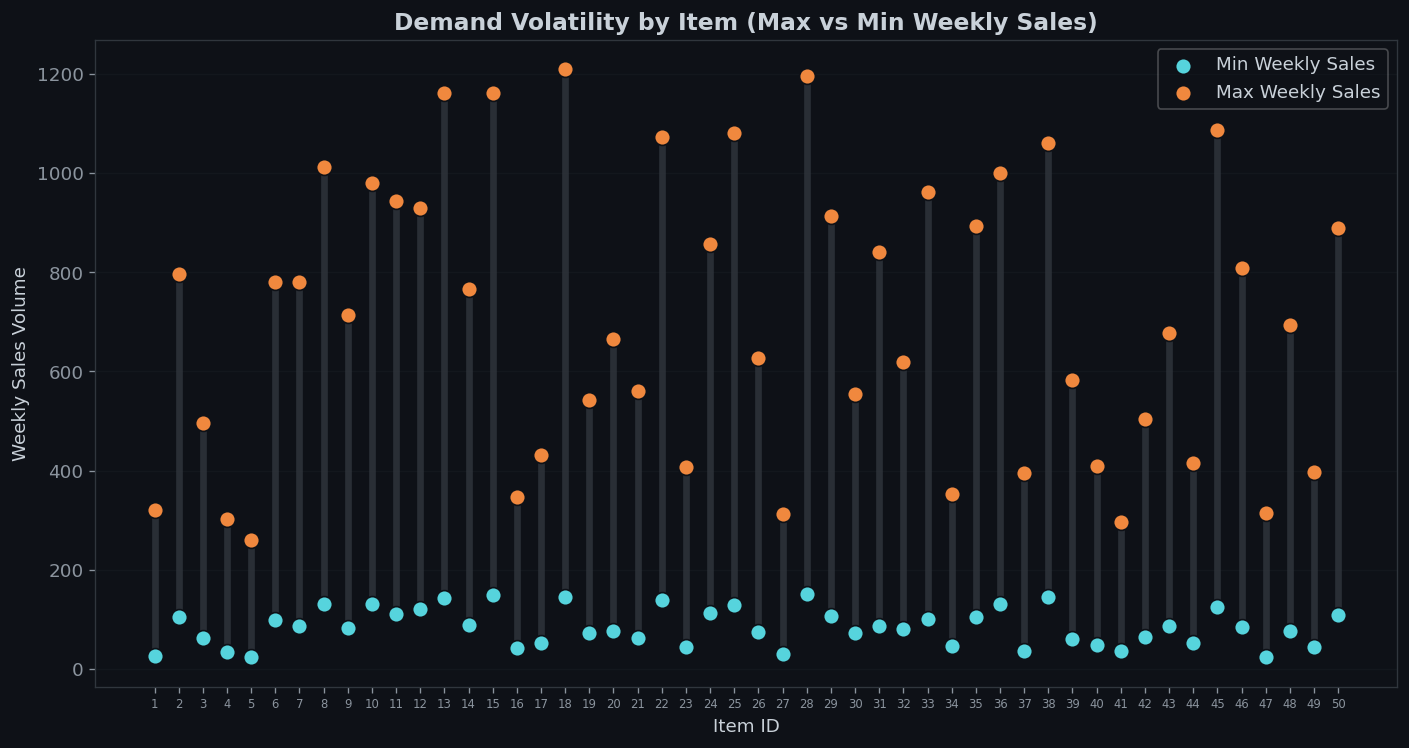

In [137]:
# 4b. Demand Volatility by Item — dumbbell (Min vs Max Weekly Sales)
item_volatility = df_weekly.groupby('item')['weekly_sales'].agg(['min', 'max']).reset_index()
item_volatility['diff'] = item_volatility['max'] - item_volatility['min']
item_volatility = item_volatility.sort_values('item')  # keep natural item order

fig, ax = plt.subplots(figsize=(14, 7))

# Vertical lines (min → max) for each item
ax.vlines(
    x=item_volatility['item'].astype(str),
    ymin=item_volatility['min'],
    ymax=item_volatility['max'],
    color='#30363d', alpha=0.8, linewidth=4,
)
ax.scatter(
    item_volatility['item'].astype(str), item_volatility['min'],
    color=PALETTE[7], s=90, label='Min Weekly Sales', zorder=3, edgecolor='#0e1117',
)
ax.scatter(
    item_volatility['item'].astype(str), item_volatility['max'],
    color=PALETTE[1], s=90, label='Max Weekly Sales', zorder=3, edgecolor='#0e1117',
)

ax.set(title='Demand Volatility by Item (Max vs Min Weekly Sales)',
       xlabel='Item ID', ylabel='Weekly Sales Volume')
ax.legend(framealpha=0.3)
ax.grid(axis='y', alpha=0.3)
ax.tick_params(axis='x', labelsize=7)
save(fig, '4b_item_volatility.png')
plt.show()

---
## Section 5 — Correlation & Lag Validation

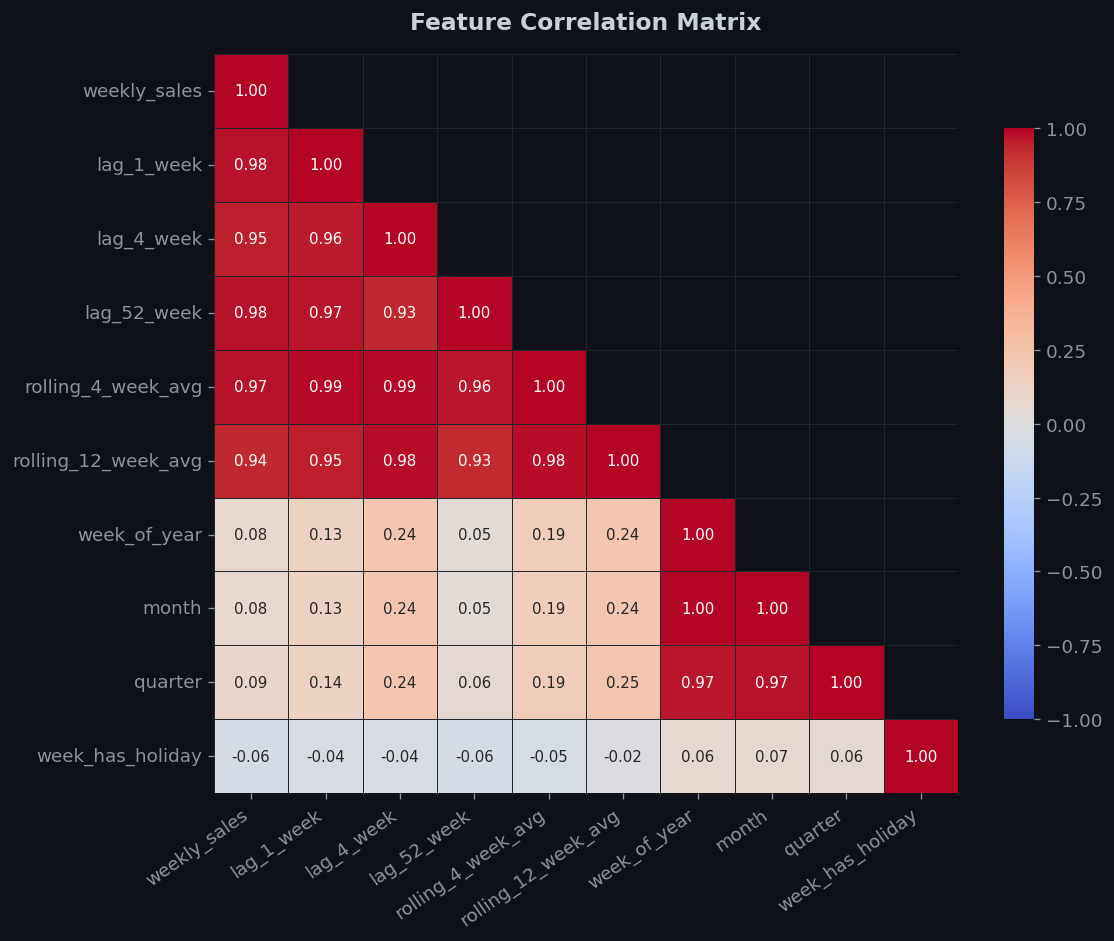

In [138]:
# 5b. Pearson correlation matrix of lag/rolling features with weekly_sales
corr_cols = ['weekly_sales', 'lag_1_week', 'lag_4_week', 'lag_52_week',
             'rolling_4_week_avg', 'rolling_12_week_avg',
             'week_of_year', 'month', 'quarter', 'week_has_holiday']

corr_matrix = df_gold[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, ax=ax, linewidths=0.5, linecolor='#21262d',
    cbar_kws={'shrink': 0.8}, annot_kws={'size': 9},
    vmin=-1, vmax=1
)
ax.set_title('Feature Correlation Matrix', pad=15)
plt.xticks(rotation=35, ha='right')
save(fig, '5b_correlation_matrix.png')
plt.show()

---
## Section 6 — Key Insights

### 🔍 Summary of Findings

**1. Clear Yearly Seasonality with Consistent Shape**  
The continuous weekly sales trend (chart 2a) reveals a pronounced and repeating seasonal cycle across all five years (2013–2017). Demand ramps up from spring (~week 14), peaks during summer (weeks 26–32), and dips sharply in late December/early January (weeks 49–1). The week-of-year heatmap (chart 2c) confirms this pattern is consistent year over year, with the same hot/cold zones appearing in every row.

**2. Steady Year-over-Year Growth**  
The single trend line in chart 2a shows each successive year's peak surpassing the previous one, indicating organic demand growth across the entire catalog. This upward drift means time-aware features (e.g., year or a simple trend counter) could be useful for the forecasting model.

**3. Weekday-Level Patterns are Uniform**  
The daily purchasing intensity heatmap (chart 2d) shows no strong day-of-week effect — sales volume is roughly even across Monday–Sunday for each week of the year. This suggests the stores sell everyday consumer goods (e.g., groceries, household staples) rather than weekend-skewed categories like electronics or dining.

**4. High Demand Variance Between Items**  
The dumbbell chart (4b) shows substantial volatility differences across items. Some items have a narrow min–max band (stable, predictable demand), while others swing widely — their peak-week sales can be 5–10× their trough. These high-volatility items may benefit from separate forecasting strategies or safety-stock buffers.

**5. Store Baselines Differ but Seasonal Shapes are Identical**  
All 10 stores exhibit the same seasonal curve (chart 3b), but their absolute sales levels differ (Store 2 highest, Store 7 lowest). This validates encoding `store` as a categorical feature — the model must learn each store's independent baseline rather than treating it as a continuous scale.

**6. Lag Features are the Strongest Predictors**  
The correlation matrix (chart 5b) confirms `lag_1_week` has the strongest linear relationship with `weekly_sales` (r ≈ 0.95+). `rolling_4_week_avg` and `rolling_12_week_avg` are also strong predictors (r > 0.90), validating the Gold-layer feature engineering decisions.

**7. Holiday Correlation is Very Low — and That's Expected**  
The `week_has_holiday` feature shows near-zero Pearson correlation with `weekly_sales`. Several factors explain this:

- **Product mix:** The dataset contains 50 anonymized items sold at 10 stores with no product-category metadata. The uniform day-of-week purchasing pattern (chart 2d) strongly suggests these are **everyday consumer staples** (groceries, household essentials) — precisely the categories whose demand is largely *inelastic* to public holidays. Unlike discretionary goods (electronics, apparel, gifts), staple items are purchased at a steady rate regardless of whether a given week includes a holiday.
- **Aggregation level:** The holiday flag is binary at the *weekly* level. A single holiday day within a 7-day window may simply shift purchases by a day or two (pre-buying or post-buying) rather than changing the weekly total, washing out any effect.
- **Uniform distribution:** 28.6% of all weekly rows are flagged as holiday weeks — a relatively high proportion that further dilutes any signal, since many different holidays with opposing effects (e.g., Christmas vs. Labor Day) are lumped together.

**8. `week_of_year` Encodes Strong Seasonal Signal**  
The heatmap (2c) demonstrates that `week_of_year` alone captures the dominant seasonal pattern, justifying its inclusion as a core feature alongside lag and rolling statistics.


In [139]:
# Summary statistics for reference
print('═' * 60)
print('  DATASET SUMMARY')
print('═' * 60)
print(f'  Date range     : {df_daily["date"].min().date()} → {df_daily["date"].max().date()}')
print(f'  Stores         : {df_weekly["store"].nunique()} (IDs: {sorted(df_weekly["store"].unique())})')
print(f'  Items          : {df_weekly["item"].nunique()}')
print(f'  Daily rows     : {len(df_daily):,}')
print(f'  Weekly rows    : {len(df_weekly):,}')
print(f'  Gold rows      : {len(df_gold):,} (after lag/rolling feature filtering)')
print(f'  Avg weekly sale: {df_weekly["weekly_sales"].mean():.1f} units')
print(f'  Max weekly sale: {df_weekly["weekly_sales"].max():,} units')
print(f'  Holiday weeks  : {df_weekly["week_has_holiday"].sum():,} / {len(df_weekly):,} ({df_weekly["week_has_holiday"].mean()*100:.1f}%)')
print('═' * 60)
print(f'\n  Plots saved to: {os.path.abspath(PLOTS_DIR)}')

════════════════════════════════════════════════════════════
  DATASET SUMMARY
════════════════════════════════════════════════════════════
  Date range     : 2013-01-01 → 2017-12-31
  Stores         : 10 (IDs: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)])
  Items          : 50
  Daily rows     : 913,000
  Weekly rows    : 131,000
  Gold rows      : 105,000 (after lag/rolling feature filtering)
  Avg weekly sale: 364.2 units
  Max weekly sale: 1,210 units
  Holiday weeks  : 37,500 / 131,000 (28.6%)
════════════════════════════════════════════════════════════

  Plots saved to: /Users/ahmedmohamady/University/Distributed Data Analysis/ecommerce-demand-forecasting/results/plots
